# Dataset Basics: Comprehensive Overview

**Research Paper EDA - Part 1: Dataset Fundamentals**

This notebook provides a comprehensive analysis of the VLM Router benchmark dataset, focusing on:
1. Dataset composition and structure
2. Sample distribution across configs, tasks, and splits
3. Prompt and ground truth characteristics
4. Data quality and completeness metrics
5. Visual examples from the dataset

---

In [1]:
# === Path Setup ===
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ARTEMIS_DIR = NOTEBOOK_DIR.parent.parent.parent
ROOT_DIR = ARTEMIS_DIR.parent.parent

for p in [str(ARTEMIS_DIR), str(ROOT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f" ARTEMIS_DIR: {ARTEMIS_DIR}")

📁 ARTEMIS_DIR: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final


In [2]:
# === Imports ===
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from PIL import Image
from collections import Counter

from ares.db.connection import get_engine
from ares.configs.db_config import TABLES, MODEL_NAMES

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# DB Connection
engine = get_engine()
print(' Imports successful!')
print(f' Models in benchmark: {MODEL_NAMES}')

✓ Imports successful!
✓ Models in benchmark: ['deepseek_ocr', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking', 'gemma_3_27b']


---
## 1. Dataset Overview

High-level statistics about the benchmark dataset size and structure.

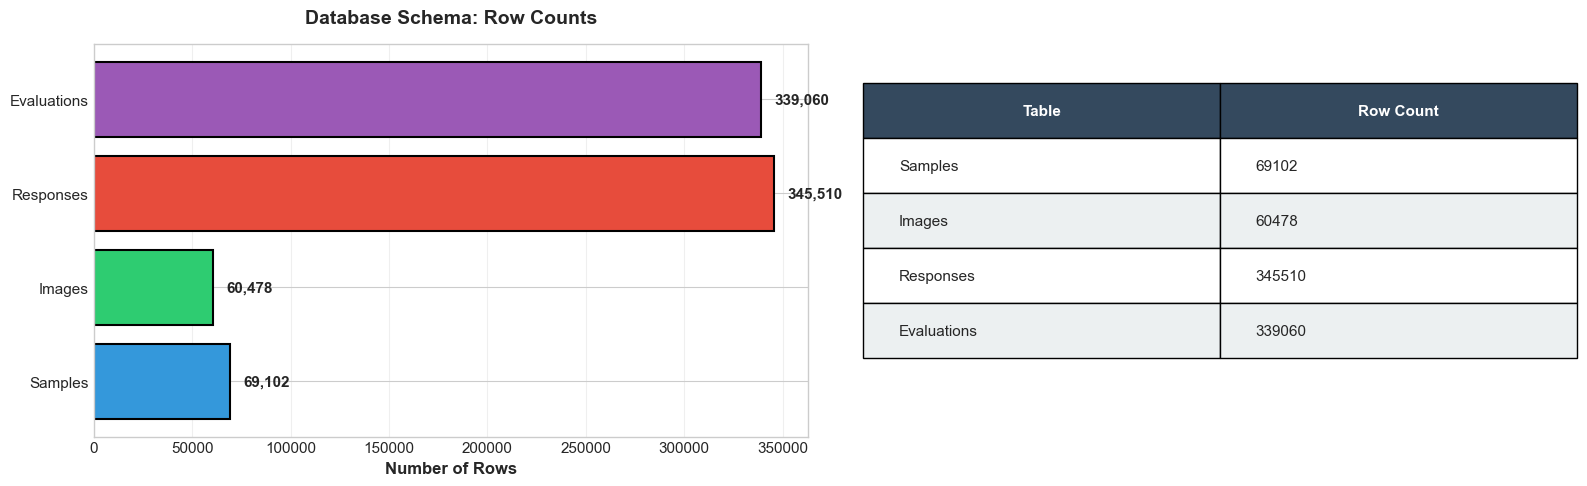


BENCHMARK DATASET SUMMARY
Samples                       69,102 rows
Images                        60,478 rows
Responses                    345,510 rows
Evaluations                  339,060 rows


In [3]:
# Table statistics
table_stats = []
with engine.connect() as conn:
    for name, table in TABLES.items():
        count = conn.execute(text(f'SELECT COUNT(*) FROM {table}')).scalar()
        table_stats.append({'Table': name.title(), 'Table Name': table, 'Row Count': count})

df_tables = pd.DataFrame(table_stats)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
bars = ax1.barh(df_tables['Table'], df_tables['Row Count'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Number of Rows', fontsize=12, fontweight='bold')
ax1.set_title('Database Schema: Row Counts', fontsize=14, pad=15)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, df_tables['Row Count']):
    ax1.text(val + max(df_tables['Row Count'])*0.02, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontweight='bold', fontsize=11)

# Table display
ax2.axis('off')
table_data = df_tables[['Table', 'Row Count']].values
table = ax2.table(cellText=table_data, colLabels=['Table', 'Row Count'],
                  cellLoc='left', loc='center', bbox=[0, 0.2, 1, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(2):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data)+1):
    for j in range(2):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        table[(i, j)].set_edgecolor('black')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("BENCHMARK DATASET SUMMARY")
print("="*70)
for _, row in df_tables.iterrows():
    print(f"{row['Table']:20} {row['Row Count']:>15,} rows")
print("="*70)

---
## 2. Sample Distribution Analysis

Understanding the composition of our benchmark across different dimensions.

In [4]:
# Load all samples
df_samples = pd.read_sql('SELECT * FROM vlm_samples', engine)
print(f'\n Total benchmark samples: {len(df_samples):,}\n')
print(f'   Unique source configs: {df_samples["source_config"].nunique()}')
print(f'   Unique router tasks: {df_samples["router_task"].nunique()}')
print(f'   Unique ground truth types: {df_samples["ground_truth_type"].nunique()}')
print(f'   Data splits: {df_samples["data_split"].unique().tolist()}')


📊 Total benchmark samples: 69,102

   Unique source configs: 48
   Unique router tasks: 30
   Unique ground truth types: 4
   Data splits: ['test', 'train', 'val']


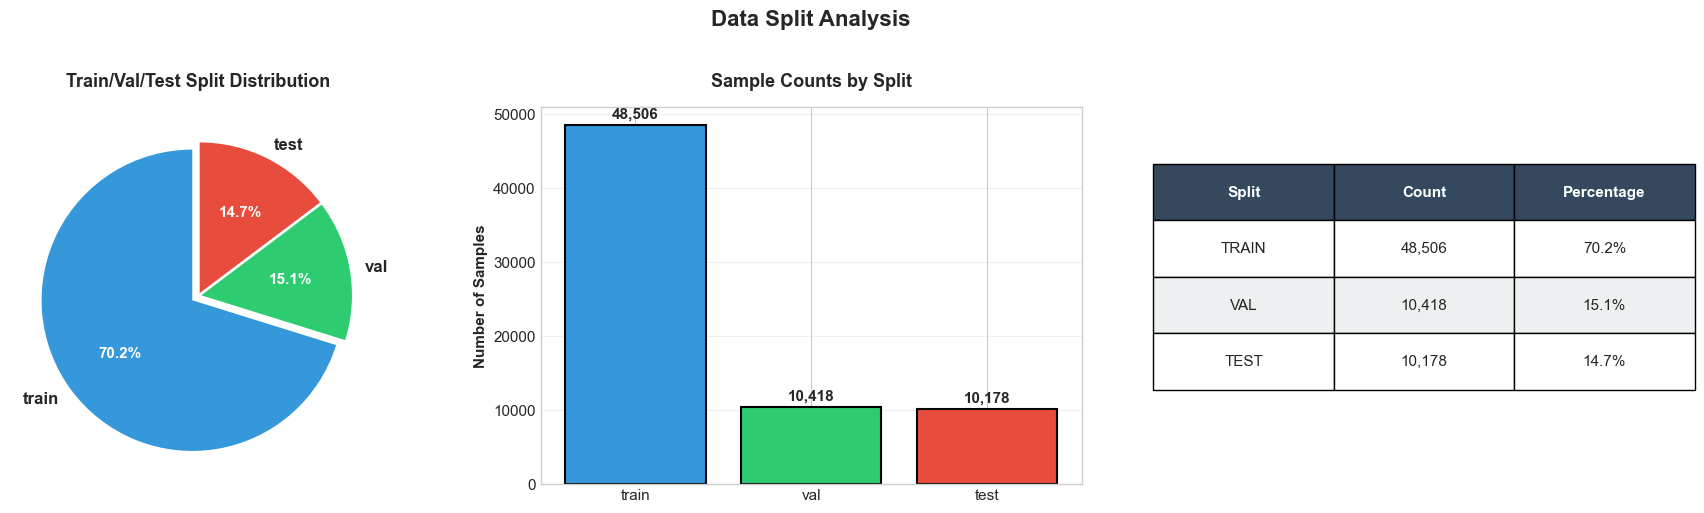


Data Split Summary:
  TRAIN    48,506 samples ( 70.2%)
  VAL      10,418 samples ( 15.1%)
  TEST     10,178 samples ( 14.7%)


In [5]:
# === 2.1: Data Split Distribution ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart of splits
split_counts = df_samples['data_split'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c']
explode = [0.05, 0.02, 0.02]
wedges, texts, autotexts = axes[0].pie(split_counts, labels=split_counts.index, autopct='%1.1f%%',
                                         colors=colors, startangle=90, explode=explode,
                                         textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Train/Val/Test Split Distribution', pad=15)

# Make percentage text bold and white
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

# Bar chart with counts
bars = axes[1].bar(split_counts.index, split_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Number of Samples', fontweight='bold')
axes[1].set_title('Sample Counts by Split', pad=15)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, split_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + split_counts.max()*0.02,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# Table with detailed stats
axes[2].axis('off')
split_stats = []
for split in ['train', 'val', 'test']:
    count = split_counts.get(split, 0)
    pct = (count / len(df_samples) * 100) if len(df_samples) > 0 else 0
    split_stats.append([split.upper(), f'{count:,}', f'{pct:.1f}%'])

table = axes[2].table(cellText=split_stats, colLabels=['Split', 'Count', 'Percentage'],
                      cellLoc='center', loc='center', bbox=[0, 0.25, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style table
for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, 4):
    for j in range(3):
        table[(i, j)].set_edgecolor('black')
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')

plt.suptitle('Data Split Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nData Split Summary:")
for split, count in split_counts.items():
    print(f"  {split.upper():6} {count:>8,} samples ({count/len(df_samples)*100:>5.1f}%)")

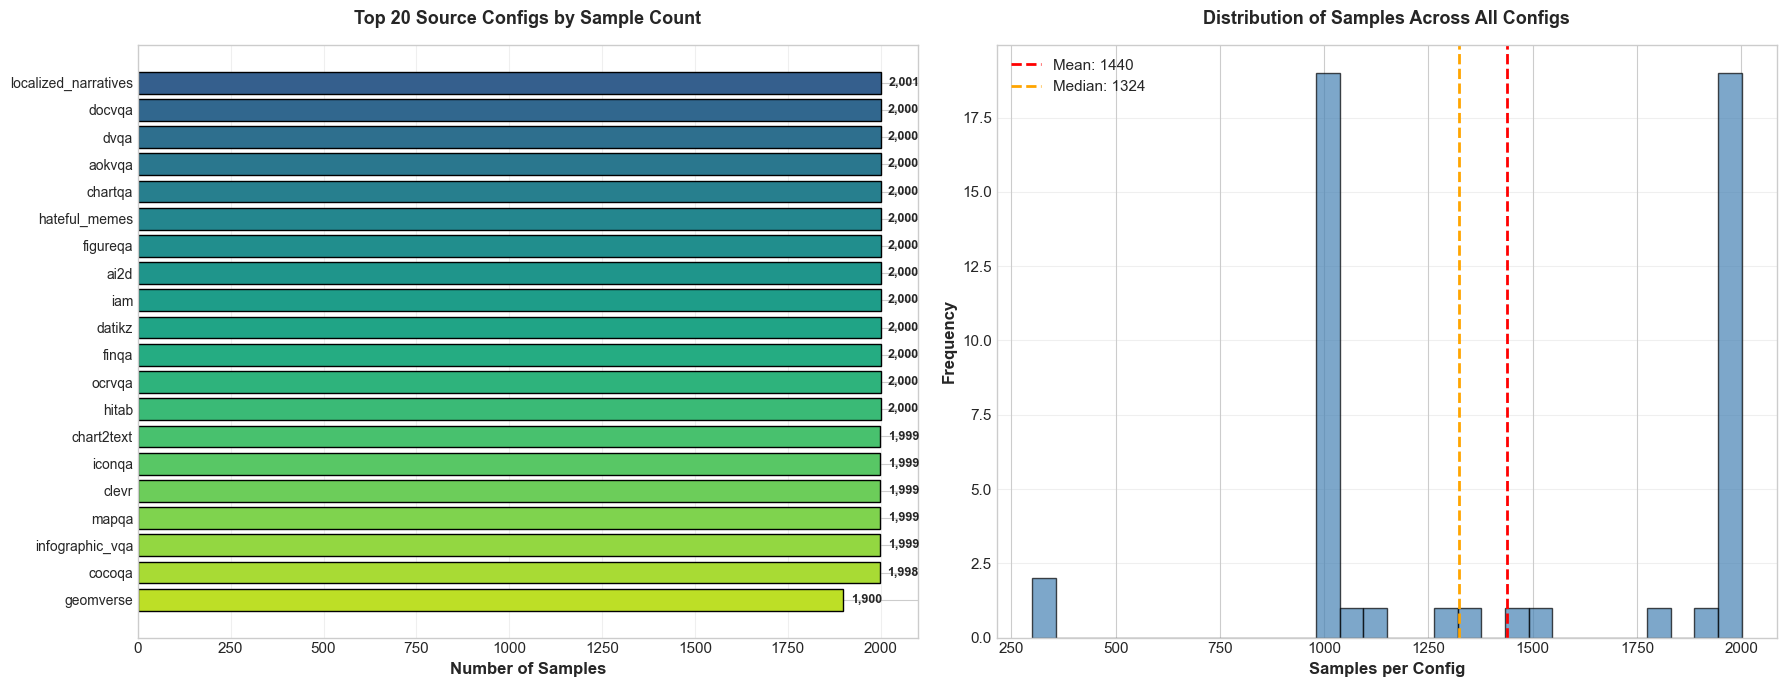


Source Config Statistics:
  Total configs: 48
  Mean samples per config: 1439.6
  Median samples per config: 1324
  Min samples: 300
  Max samples: 2001


In [6]:
# === 2.2: Source Config Distribution ===
config_counts = df_samples['source_config'].value_counts().head(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal bar chart
y_pos = np.arange(len(config_counts))
colors_grad = plt.cm.viridis(np.linspace(0.3, 0.9, len(config_counts)))
bars = ax1.barh(y_pos, config_counts.values, color=colors_grad, edgecolor='black', linewidth=1)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(config_counts.index, fontsize=10)
ax1.set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
ax1.set_title('Top 20 Source Configs by Sample Count', pad=15)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, config_counts.values)):
    ax1.text(val + config_counts.max()*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Distribution histogram
all_config_counts = df_samples['source_config'].value_counts()
ax2.hist(all_config_counts.values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(all_config_counts.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {all_config_counts.mean():.0f}')
ax2.axvline(all_config_counts.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {all_config_counts.median():.0f}')
ax2.set_xlabel('Samples per Config', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Samples Across All Configs', pad=15)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSource Config Statistics:")
print(f"  Total configs: {df_samples['source_config'].nunique()}")
print(f"  Mean samples per config: {all_config_counts.mean():.1f}")
print(f"  Median samples per config: {all_config_counts.median():.0f}")
print(f"  Min samples: {all_config_counts.min()}")
print(f"  Max samples: {all_config_counts.max()}")

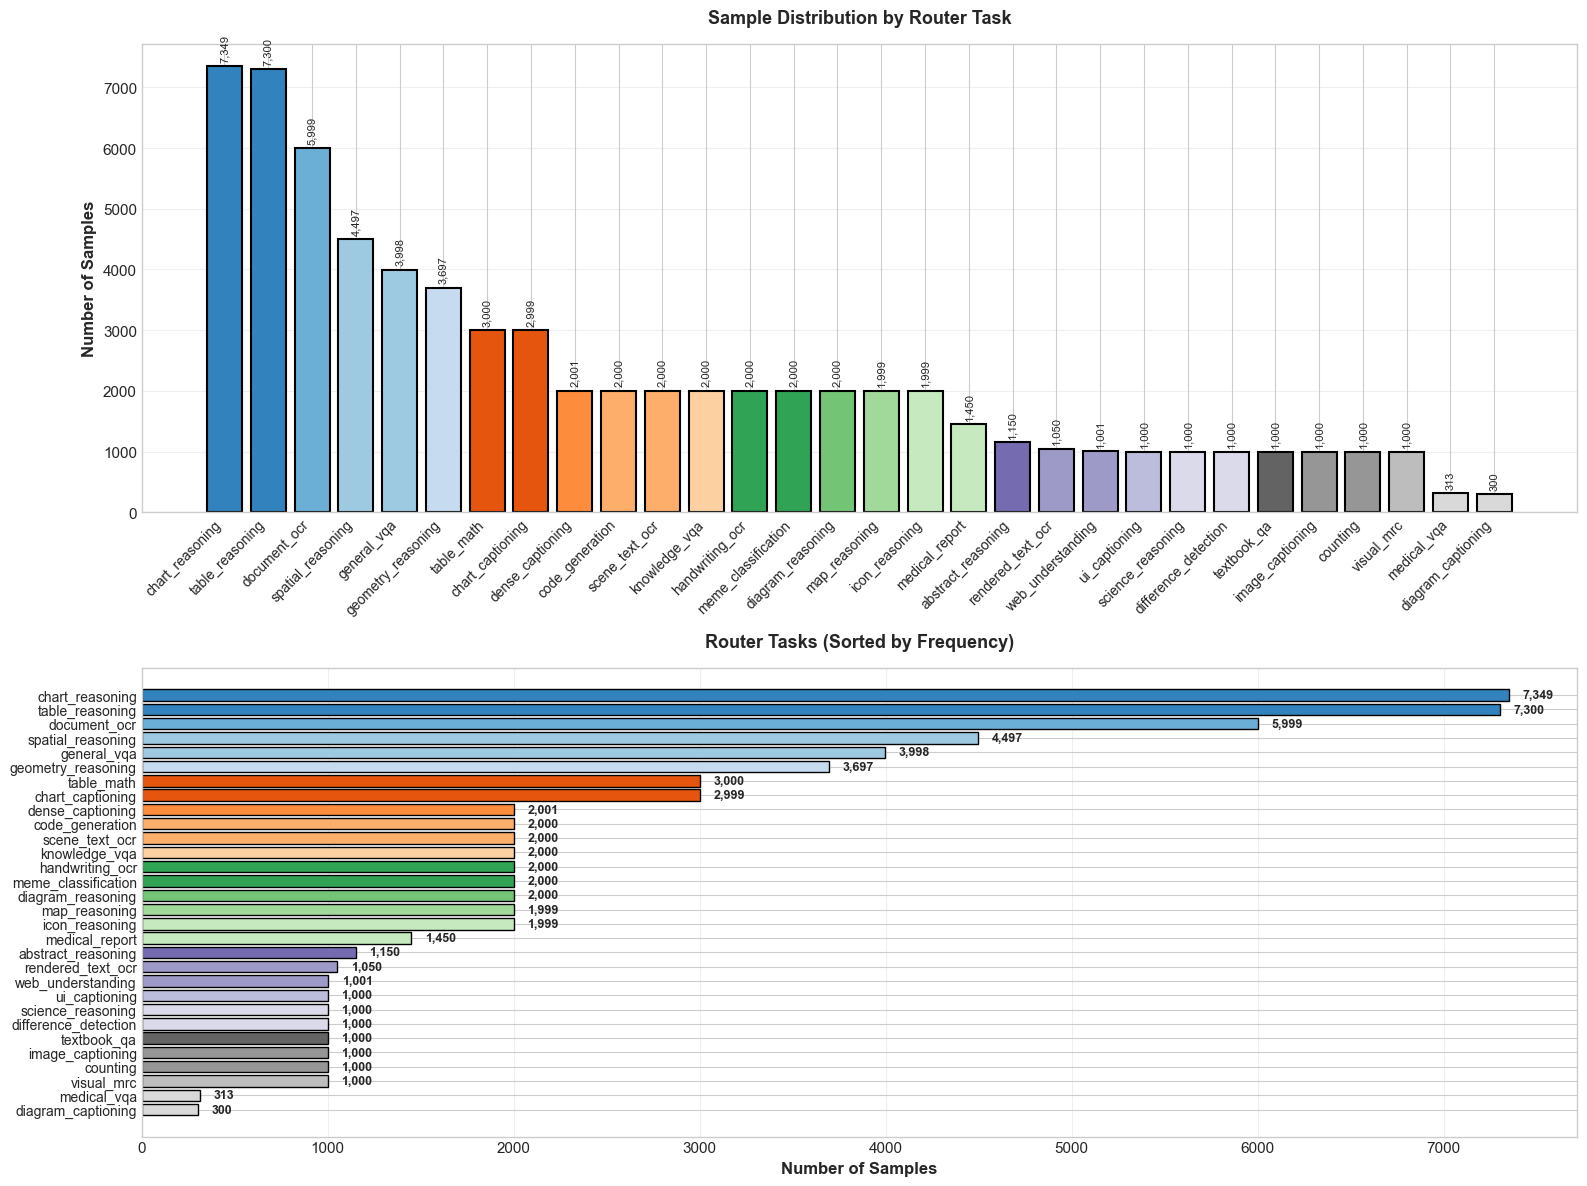


Router Task Summary (30 unique tasks):
  chart_reasoning                 7,349 samples ( 10.6%)
  table_reasoning                 7,300 samples ( 10.6%)
  document_ocr                    5,999 samples (  8.7%)
  spatial_reasoning               4,497 samples (  6.5%)
  general_vqa                     3,998 samples (  5.8%)
  geometry_reasoning              3,697 samples (  5.4%)
  table_math                      3,000 samples (  4.3%)
  chart_captioning                2,999 samples (  4.3%)
  dense_captioning                2,001 samples (  2.9%)
  code_generation                 2,000 samples (  2.9%)


In [7]:
# === 2.3: Router Task Distribution ===
task_counts = df_samples['router_task'].value_counts()

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Bar chart
colors_task = plt.cm.tab20c(np.linspace(0, 1, len(task_counts)))
bars = axes[0].bar(range(len(task_counts)), task_counts.values, color=colors_task,
                    edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(task_counts)))
axes[0].set_xticklabels(task_counts.index, rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Sample Distribution by Router Task', pad=15)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, task_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + task_counts.max()*0.01,
                 f'{val:,}', ha='center', fontsize=8, rotation=90, va='bottom')

# Horizontal bar for better readability
y_pos = np.arange(len(task_counts))
bars2 = axes[1].barh(y_pos, task_counts.values, color=colors_task, edgecolor='black', linewidth=1)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(task_counts.index, fontsize=10)
axes[1].set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
axes[1].set_title('Router Tasks (Sorted by Frequency)', pad=15)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars2, task_counts.values):
    axes[1].text(val + task_counts.max()*0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRouter Task Summary ({len(task_counts)} unique tasks):")
for task, count in task_counts.head(10).items():
    print(f"  {task:30} {count:>6,} samples ({count/len(df_samples)*100:>5.1f}%)")

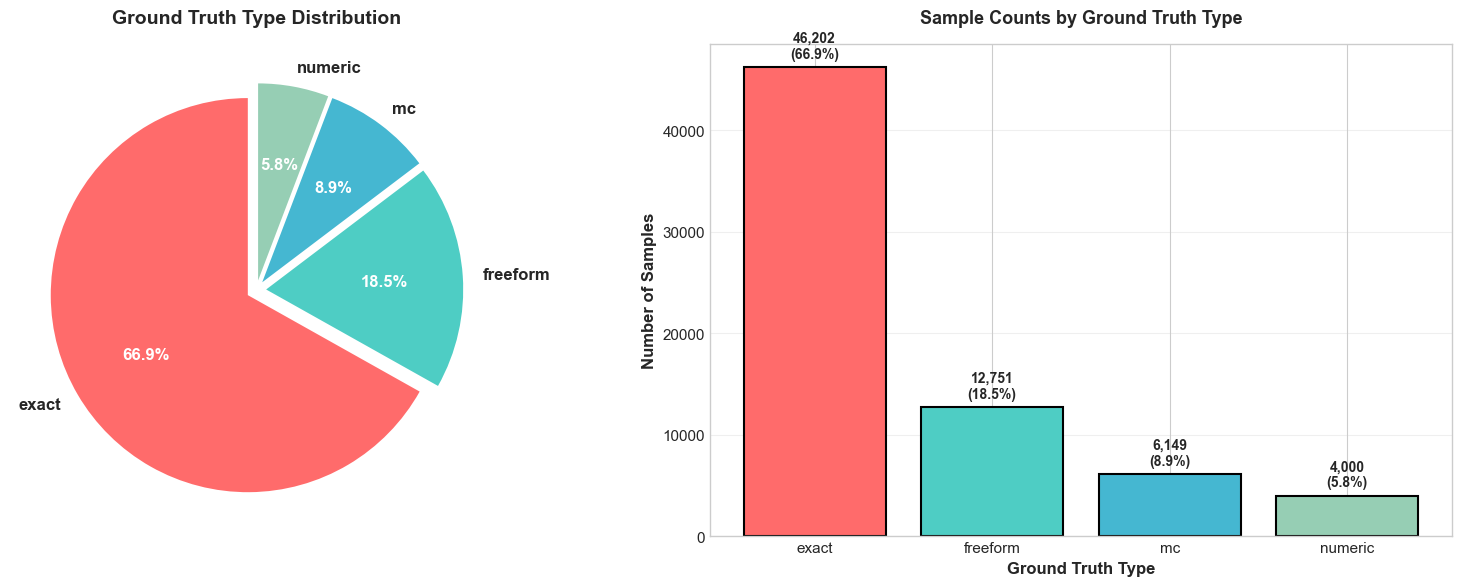


Ground Truth Type Breakdown:
  exact                  46,202 samples ( 66.9%)
  freeform               12,751 samples ( 18.5%)
  mc                      6,149 samples (  8.9%)
  numeric                 4,000 samples (  5.8%)


In [8]:
# === 2.4: Ground Truth Type Distribution ===
gt_counts = df_samples['ground_truth_type'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors_gt = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
wedges, texts, autotexts = ax1.pie(gt_counts, labels=gt_counts.index, autopct='%1.1f%%',
                                     colors=colors_gt[:len(gt_counts)], startangle=90,
                                     explode=[0.05]*len(gt_counts),
                                     textprops={'fontsize': 12, 'weight': 'bold'})
ax1.set_title('Ground Truth Type Distribution', pad=15, fontsize=14)

for autotext in autotexts:
    autotext.set_color('white')

# Bar chart
bars = ax2.bar(gt_counts.index, gt_counts.values, color=colors_gt[:len(gt_counts)],
                edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax2.set_xlabel('Ground Truth Type', fontsize=12, fontweight='bold')
ax2.set_title('Sample Counts by Ground Truth Type', pad=15)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, gt_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + gt_counts.max()*0.02,
             f'{val:,}\n({val/len(df_samples)*100:.1f}%)',
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nGround Truth Type Breakdown:")
for gt_type, count in gt_counts.items():
    print(f"  {gt_type:20} {count:>8,} samples ({count/len(df_samples)*100:>5.1f}%)")

---
## 3. Prompt & Ground Truth Characteristics

Analysis of text lengths and distributions.

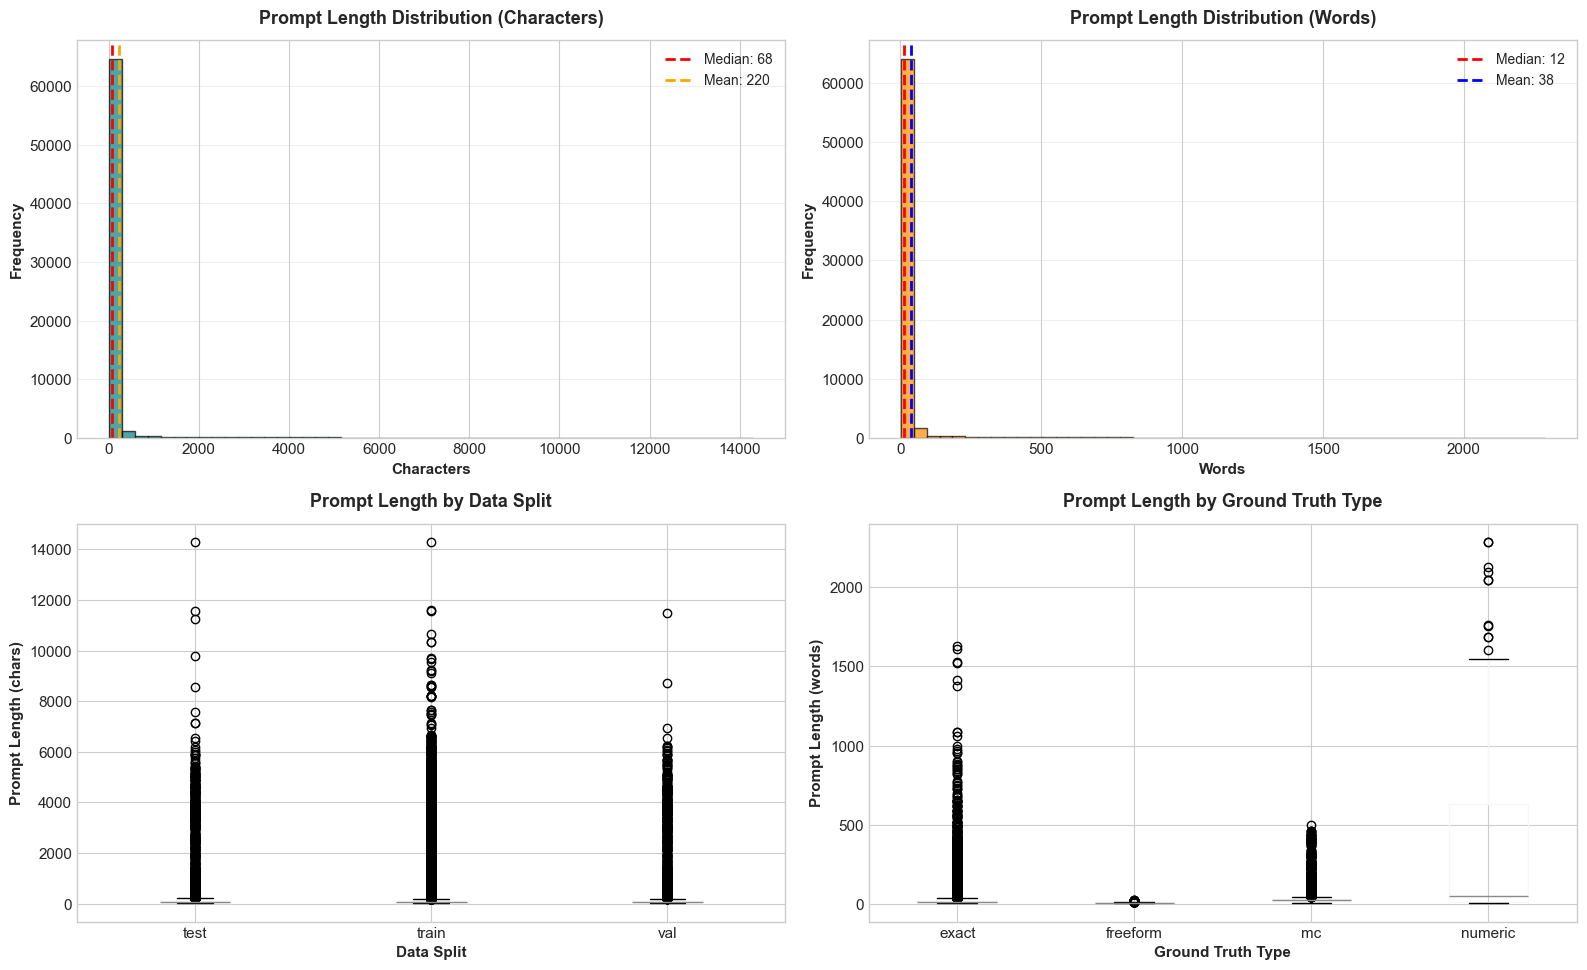


Prompt Length Statistics:
  Characters: mean=219.9, median=68, std=697.5
  Words:      mean=38.0, median=12, std=117.9


In [9]:
# === 3.1: Prompt Length Analysis ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Character length histogram
axes[0, 0].hist(df_samples['txt_prompt_length_chars'].dropna(), bins=50, 
                color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_samples['txt_prompt_length_chars'].median(), color='red',
                    linestyle='--', linewidth=2, label=f'Median: {df_samples["txt_prompt_length_chars"].median():.0f}')
axes[0, 0].axvline(df_samples['txt_prompt_length_chars'].mean(), color='orange',
                    linestyle='--', linewidth=2, label=f'Mean: {df_samples["txt_prompt_length_chars"].mean():.0f}')
axes[0, 0].set_xlabel('Characters', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Prompt Length Distribution (Characters)', pad=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)

# Word length histogram
axes[0, 1].hist(df_samples['txt_prompt_length_words'].dropna(), bins=50,
                color='darkorange', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_samples['txt_prompt_length_words'].median(), color='red',
                    linestyle='--', linewidth=2, label=f'Median: {df_samples["txt_prompt_length_words"].median():.0f}')
axes[0, 1].axvline(df_samples['txt_prompt_length_words'].mean(), color='blue',
                    linestyle='--', linewidth=2, label=f'Mean: {df_samples["txt_prompt_length_words"].mean():.0f}')
axes[0, 1].set_xlabel('Words', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Prompt Length Distribution (Words)', pad=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot by split
df_samples.boxplot(column='txt_prompt_length_chars', by='data_split', ax=axes[1, 0])
axes[1, 0].set_xlabel('Data Split', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Prompt Length (chars)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Prompt Length by Data Split', pad=12)
plt.suptitle('')

# Box plot by ground truth type
df_samples.boxplot(column='txt_prompt_length_words', by='ground_truth_type', ax=axes[1, 1])
axes[1, 1].set_xlabel('Ground Truth Type', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Prompt Length (words)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Prompt Length by Ground Truth Type', pad=12)
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nPrompt Length Statistics:")
print(f"  Characters: mean={df_samples['txt_prompt_length_chars'].mean():.1f}, "
      f"median={df_samples['txt_prompt_length_chars'].median():.0f}, "
      f"std={df_samples['txt_prompt_length_chars'].std():.1f}")
print(f"  Words:      mean={df_samples['txt_prompt_length_words'].mean():.1f}, "
      f"median={df_samples['txt_prompt_length_words'].median():.0f}, "
      f"std={df_samples['txt_prompt_length_words'].std():.1f}")

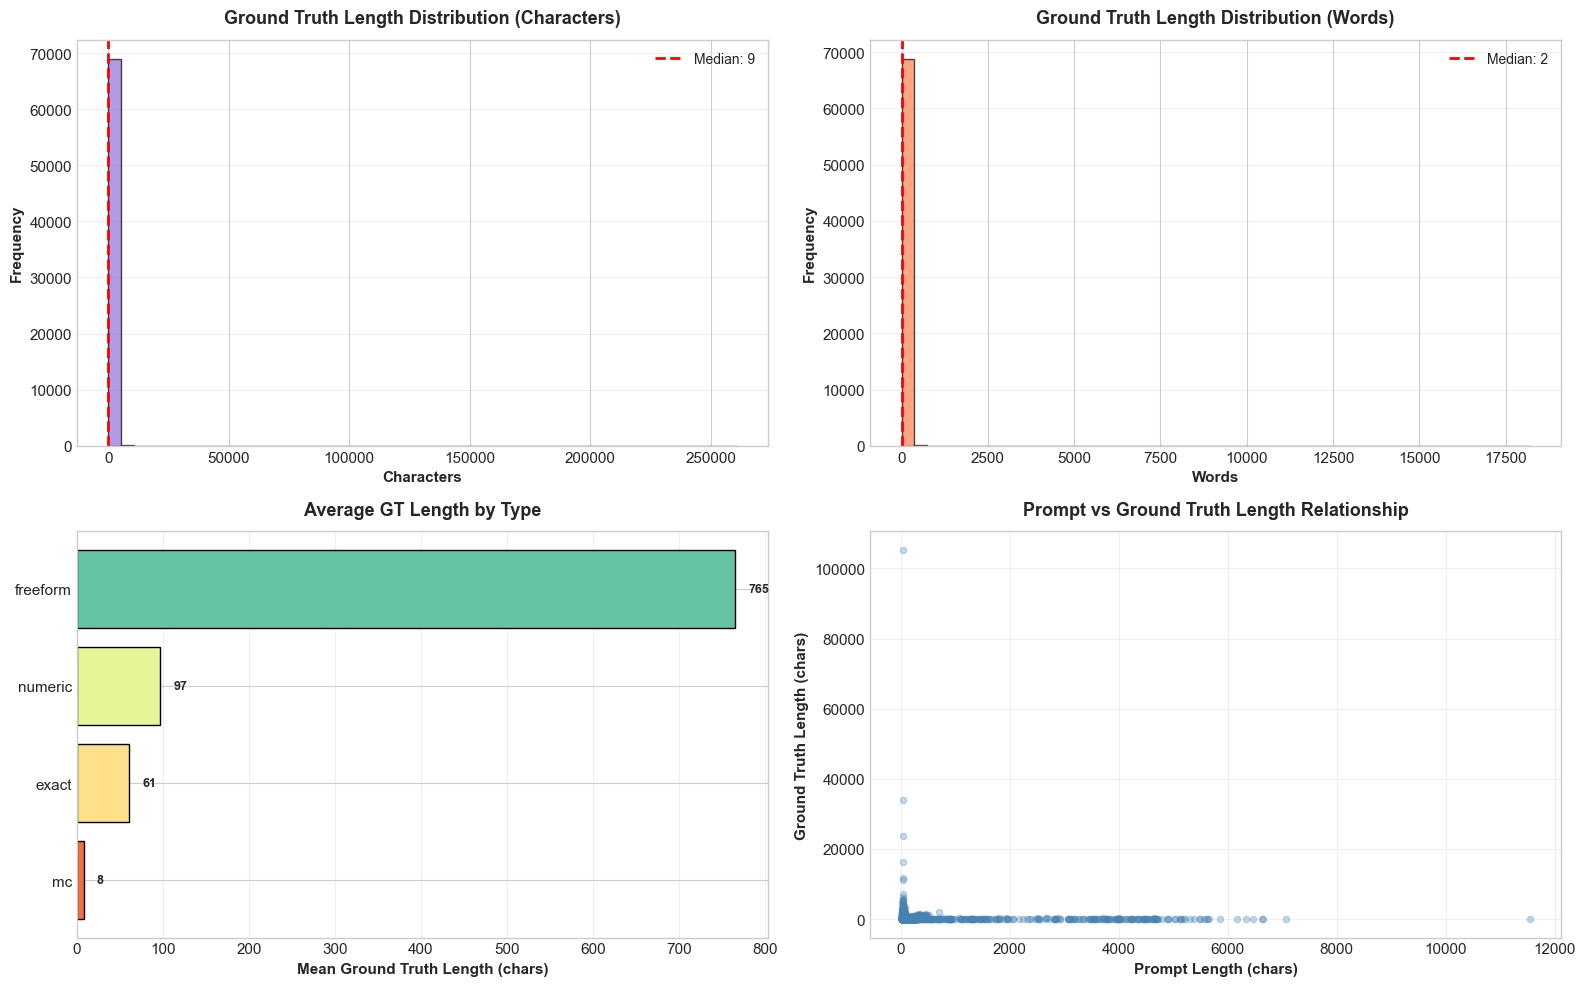


Ground Truth Length Statistics:
  Characters: mean=188.2, median=9
  Words:      mean=23.6, median=2


In [10]:
# === 3.2: Ground Truth Length Analysis ===
# Calculate ground truth lengths
df_samples['gt_length_chars'] = df_samples['ground_truth'].fillna('').str.len()
df_samples['gt_length_words'] = df_samples['ground_truth'].fillna('').str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Character length histogram
axes[0, 0].hist(df_samples['gt_length_chars'].dropna(), bins=50,
                color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_samples['gt_length_chars'].median(), color='red',
                    linestyle='--', linewidth=2, label=f'Median: {df_samples["gt_length_chars"].median():.0f}')
axes[0, 0].set_xlabel('Characters', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Ground Truth Length Distribution (Characters)', pad=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)

# Word length histogram
axes[0, 1].hist(df_samples['gt_length_words'].dropna(), bins=50,
                color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_samples['gt_length_words'].median(), color='red',
                    linestyle='--', linewidth=2, label=f'Median: {df_samples["gt_length_words"].median():.0f}')
axes[0, 1].set_xlabel('Words', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Ground Truth Length Distribution (Words)', pad=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# By ground truth type
gt_type_lengths = df_samples.groupby('ground_truth_type')['gt_length_chars'].mean().sort_values()
colors_bar = plt.cm.Spectral(np.linspace(0.2, 0.8, len(gt_type_lengths)))
bars = axes[1, 0].barh(gt_type_lengths.index, gt_type_lengths.values, color=colors_bar,
                        edgecolor='black', linewidth=1)
axes[1, 0].set_xlabel('Mean Ground Truth Length (chars)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Average GT Length by Type', pad=12)
axes[1, 0].grid(axis='x', alpha=0.3)

for bar, val in zip(bars, gt_type_lengths.values):
    axes[1, 0].text(val + gt_type_lengths.max()*0.02, bar.get_y() + bar.get_height()/2,
                    f'{val:.0f}', va='center', fontsize=9, fontweight='bold')

# Scatter: prompt length vs GT length
sample_data = df_samples.sample(min(5000, len(df_samples)))
axes[1, 1].scatter(sample_data['txt_prompt_length_chars'], sample_data['gt_length_chars'],
                   alpha=0.3, s=20, c='steelblue')
axes[1, 1].set_xlabel('Prompt Length (chars)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Ground Truth Length (chars)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Prompt vs Ground Truth Length Relationship', pad=12)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGround Truth Length Statistics:")
print(f"  Characters: mean={df_samples['gt_length_chars'].mean():.1f}, "
      f"median={df_samples['gt_length_chars'].median():.0f}")
print(f"  Words:      mean={df_samples['gt_length_words'].mean():.1f}, "
      f"median={df_samples['gt_length_words'].median():.0f}")

---
## 4. Cross-Dimensional Analysis

Understanding relationships between different dataset dimensions.

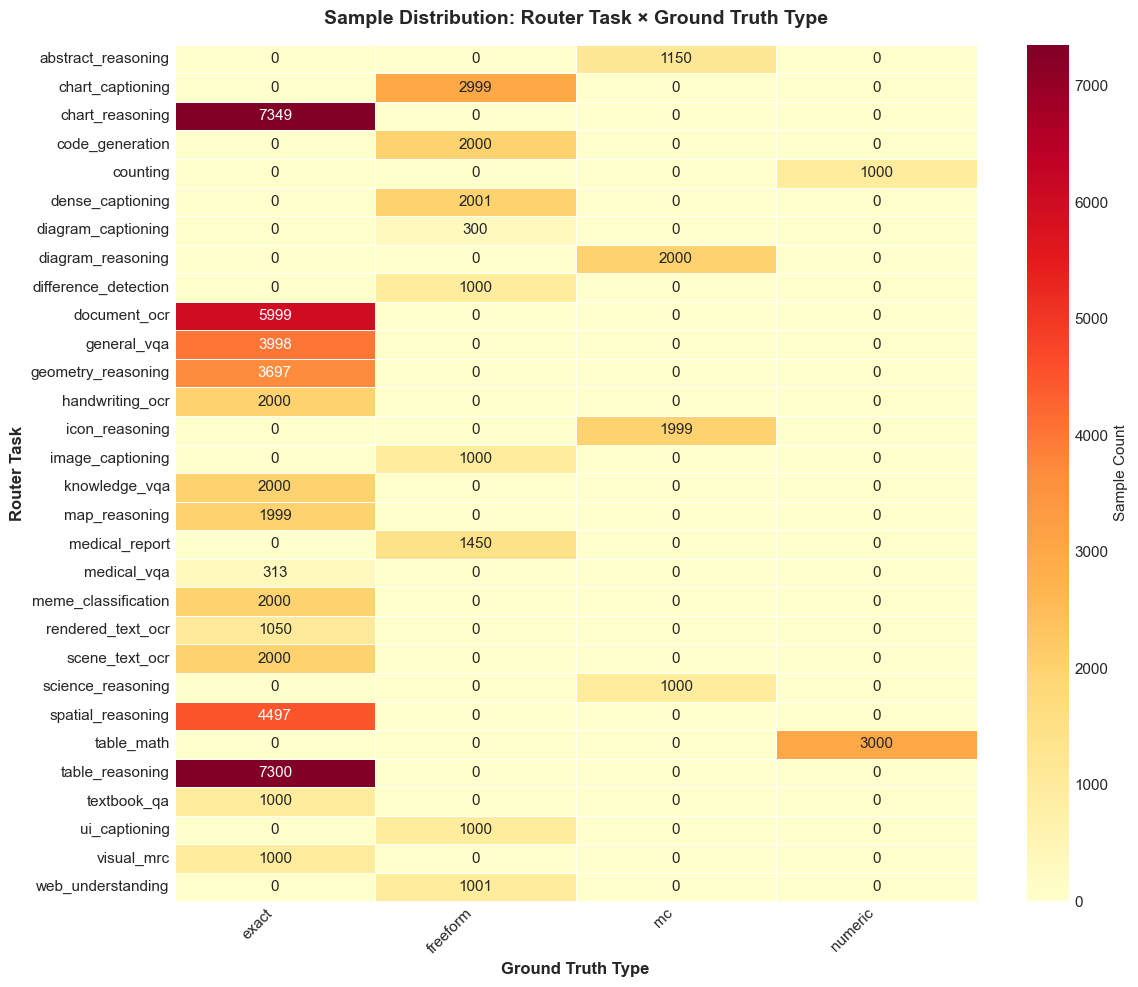

In [11]:
# === 4.1: Task × Ground Truth Type Heatmap ===
cross_tab = pd.crosstab(df_samples['router_task'], df_samples['ground_truth_type'])

plt.figure(figsize=(12, 10))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Sample Count'})
plt.title('Sample Distribution: Router Task × Ground Truth Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ground Truth Type', fontsize=12, fontweight='bold')
plt.ylabel('Router Task', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

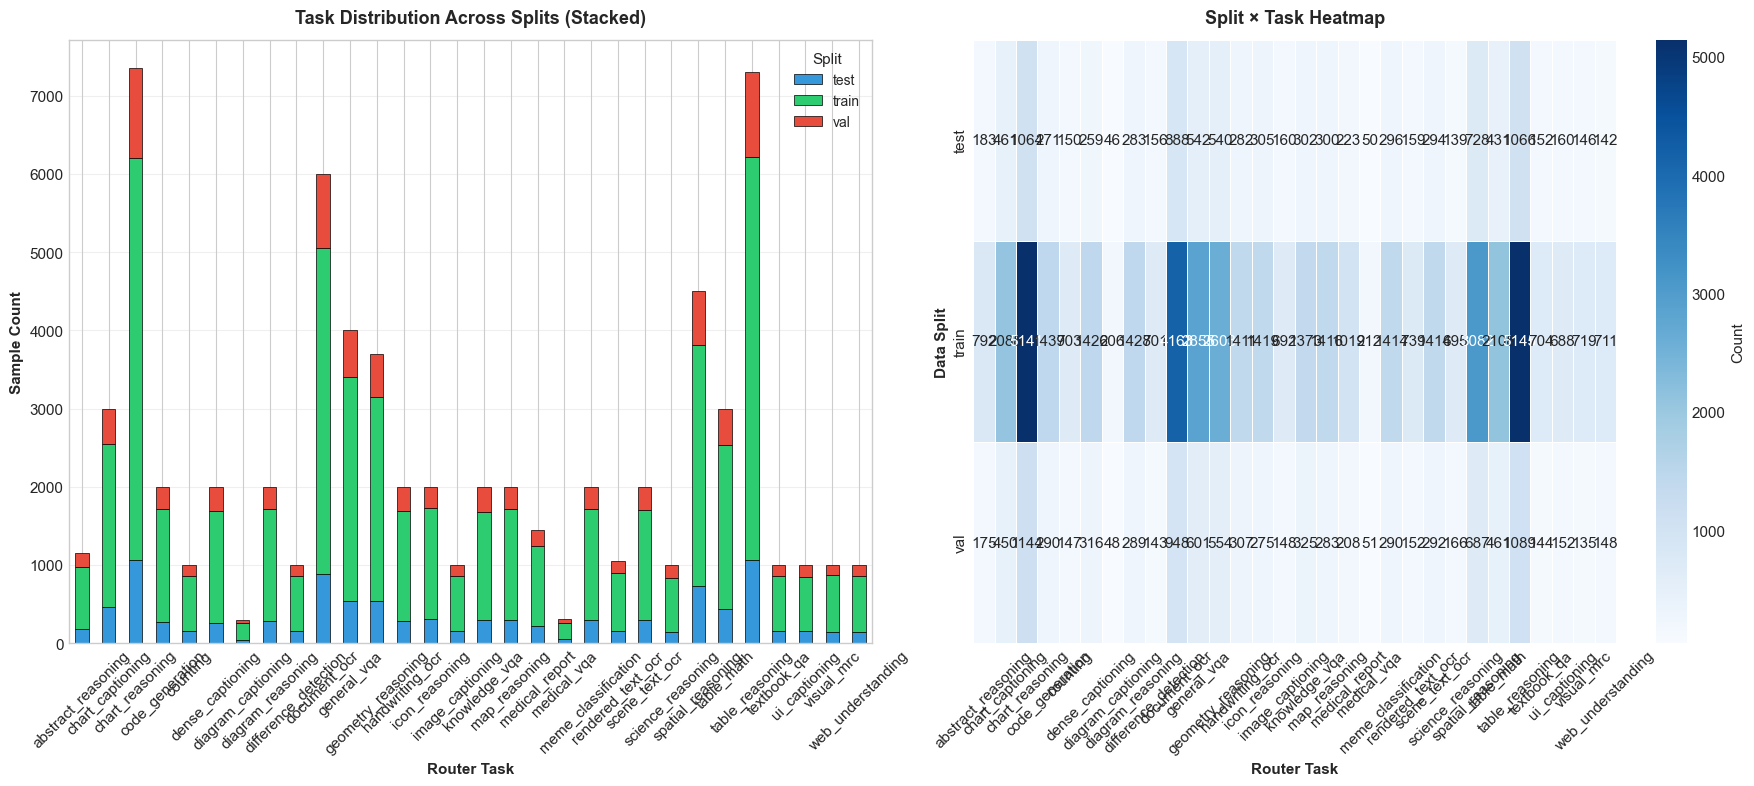

In [12]:
# === 4.2: Split × Task Distribution ===
split_task = pd.crosstab(df_samples['data_split'], df_samples['router_task'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Stacked bar chart
split_task.T.plot(kind='bar', stacked=True, ax=ax1, color=['#3498db', '#2ecc71', '#e74c3c'],
                   edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Router Task', fontsize=11, fontweight='bold')
ax1.set_ylabel('Sample Count', fontsize=11, fontweight='bold')
ax1.set_title('Task Distribution Across Splits (Stacked)', pad=12)
ax1.legend(title='Split', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Heatmap
sns.heatmap(split_task, annot=True, fmt='d', cmap='Blues', ax=ax2, linewidths=0.5,
            cbar_kws={'label': 'Count'})
ax2.set_title('Split × Task Heatmap', pad=12, fontweight='bold')
ax2.set_xlabel('Router Task', fontsize=11, fontweight='bold')
ax2.set_ylabel('Data Split', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 5. Image Characteristics

Analysis of image dimensions and properties.

In [13]:
# Load image metadata
query_img = '''
SELECT i.*, s.source_config, s.router_task
FROM vlm_images i
JOIN vlm_samples s ON i.image_id = s.image_id
LIMIT 50000
'''
df_images = pd.read_sql(query_img, engine)
print(f"\nLoaded {len(df_images):,} images for analysis")


Loaded 50,000 images for analysis


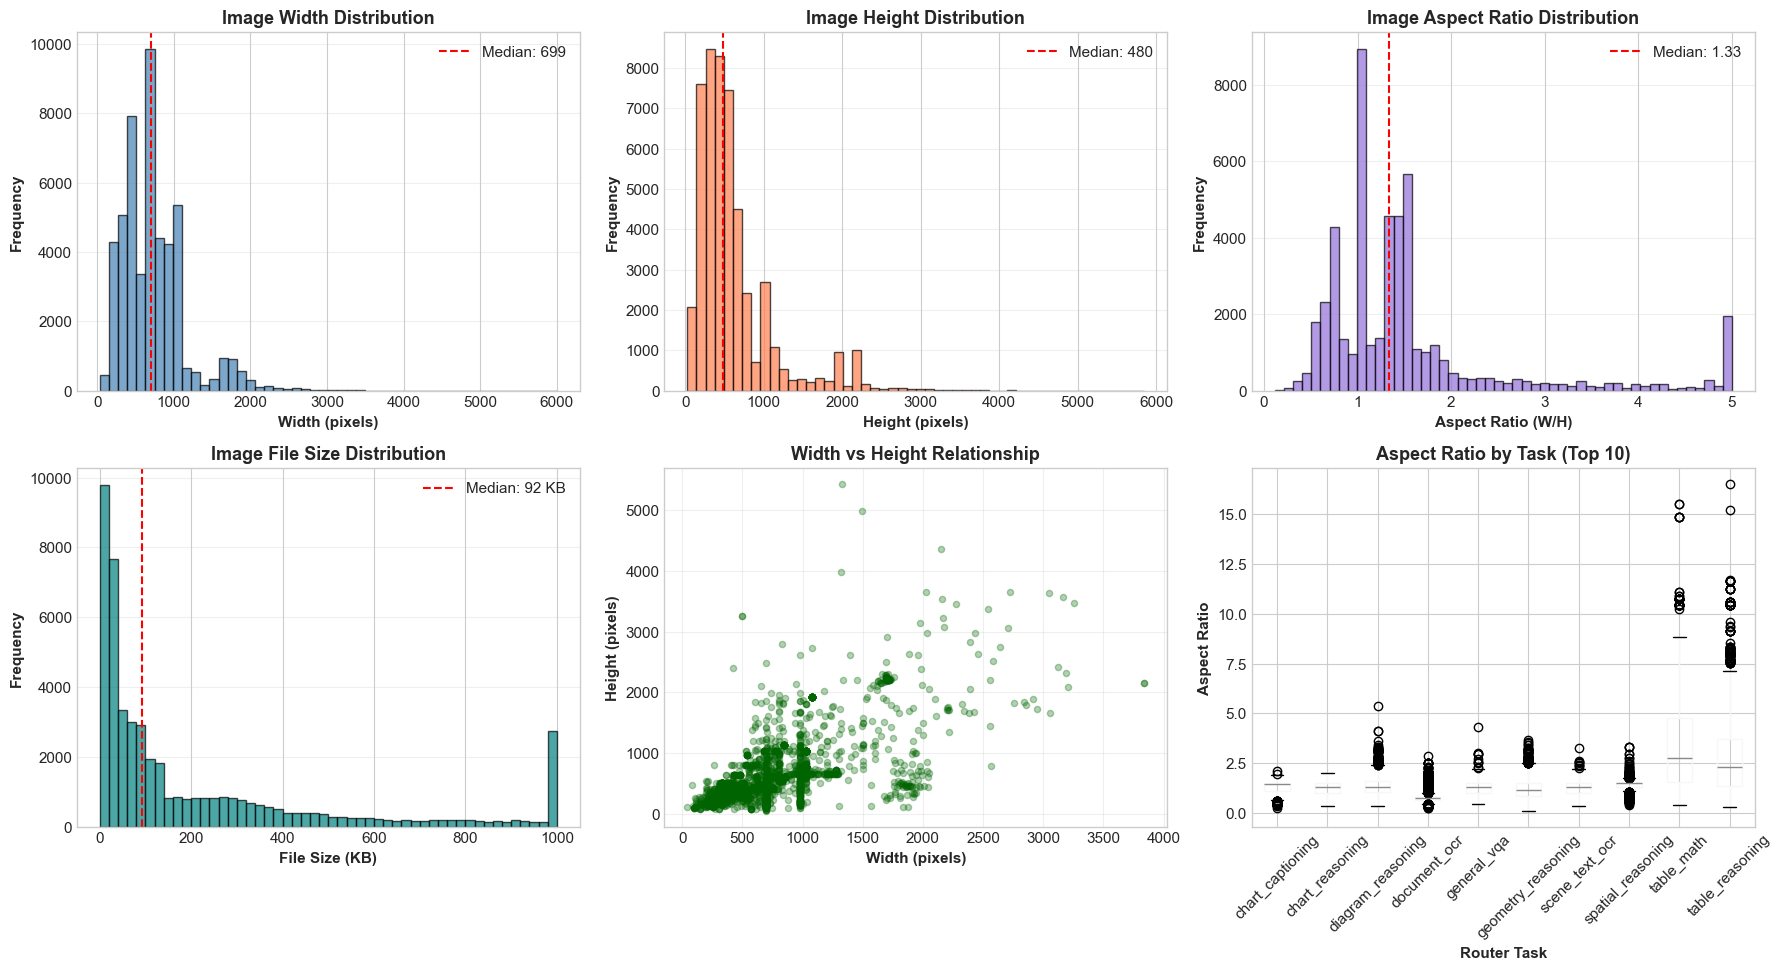


Image Statistics:
  Width:        mean=740, median=699
  Height:       mean=617, median=480
  Aspect Ratio: mean=1.62, median=1.33
  File Size:    mean=247 KB, median=92 KB


In [14]:
# === 5.1: Image Dimensions Analysis ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Width distribution
axes[0, 0].hist(df_images['img_width'].dropna(), bins=50, color='steelblue',
                edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_images['img_width'].median(), color='red', linestyle='--',
                    label=f'Median: {df_images["img_width"].median():.0f}')
axes[0, 0].set_xlabel('Width (pixels)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Image Width Distribution')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Height distribution
axes[0, 1].hist(df_images['img_height'].dropna(), bins=50, color='coral',
                edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_images['img_height'].median(), color='red', linestyle='--',
                    label=f'Median: {df_images["img_height"].median():.0f}')
axes[0, 1].set_xlabel('Height (pixels)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Image Height Distribution')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Aspect ratio distribution
axes[0, 2].hist(df_images['img_aspect_ratio'].dropna().clip(0, 5), bins=50,
                color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(df_images['img_aspect_ratio'].median(), color='red', linestyle='--',
                    label=f'Median: {df_images["img_aspect_ratio"].median():.2f}')
axes[0, 2].set_xlabel('Aspect Ratio (W/H)', fontweight='bold')
axes[0, 2].set_ylabel('Frequency', fontweight='bold')
axes[0, 2].set_title('Image Aspect Ratio Distribution')
axes[0, 2].legend()
axes[0, 2].grid(axis='y', alpha=0.3)

# File size distribution
df_images['img_size_kb'] = df_images['img_file_size_bytes'] / 1024
axes[1, 0].hist(df_images['img_size_kb'].dropna().clip(0, 1000), bins=50,
                color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df_images['img_size_kb'].median(), color='red', linestyle='--',
                    label=f'Median: {df_images["img_size_kb"].median():.0f} KB')
axes[1, 0].set_xlabel('File Size (KB)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Image File Size Distribution')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Scatter: width vs height
sample_img = df_images.sample(min(3000, len(df_images)))
axes[1, 1].scatter(sample_img['img_width'], sample_img['img_height'],
                   alpha=0.3, s=20, c='darkgreen')
axes[1, 1].set_xlabel('Width (pixels)', fontweight='bold')
axes[1, 1].set_ylabel('Height (pixels)', fontweight='bold')
axes[1, 1].set_title('Width vs Height Relationship')
axes[1, 1].grid(alpha=0.3)

# Aspect ratio by task (top 10 tasks)
top_tasks = df_images['router_task'].value_counts().head(10).index
df_top_tasks = df_images[df_images['router_task'].isin(top_tasks)]
df_top_tasks.boxplot(column='img_aspect_ratio', by='router_task', ax=axes[1, 2])
axes[1, 2].set_xlabel('Router Task', fontweight='bold')
axes[1, 2].set_ylabel('Aspect Ratio', fontweight='bold')
axes[1, 2].set_title('Aspect Ratio by Task (Top 10)')
axes[1, 2].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nImage Statistics:")
print(f"  Width:        mean={df_images['img_width'].mean():.0f}, median={df_images['img_width'].median():.0f}")
print(f"  Height:       mean={df_images['img_height'].mean():.0f}, median={df_images['img_height'].median():.0f}")
print(f"  Aspect Ratio: mean={df_images['img_aspect_ratio'].mean():.2f}, median={df_images['img_aspect_ratio'].median():.2f}")
print(f"  File Size:    mean={df_images['img_size_kb'].mean():.0f} KB, median={df_images['img_size_kb'].median():.0f} KB")

---
## 6. Visual Examples from Dataset

Display sample images from different source configs and tasks.

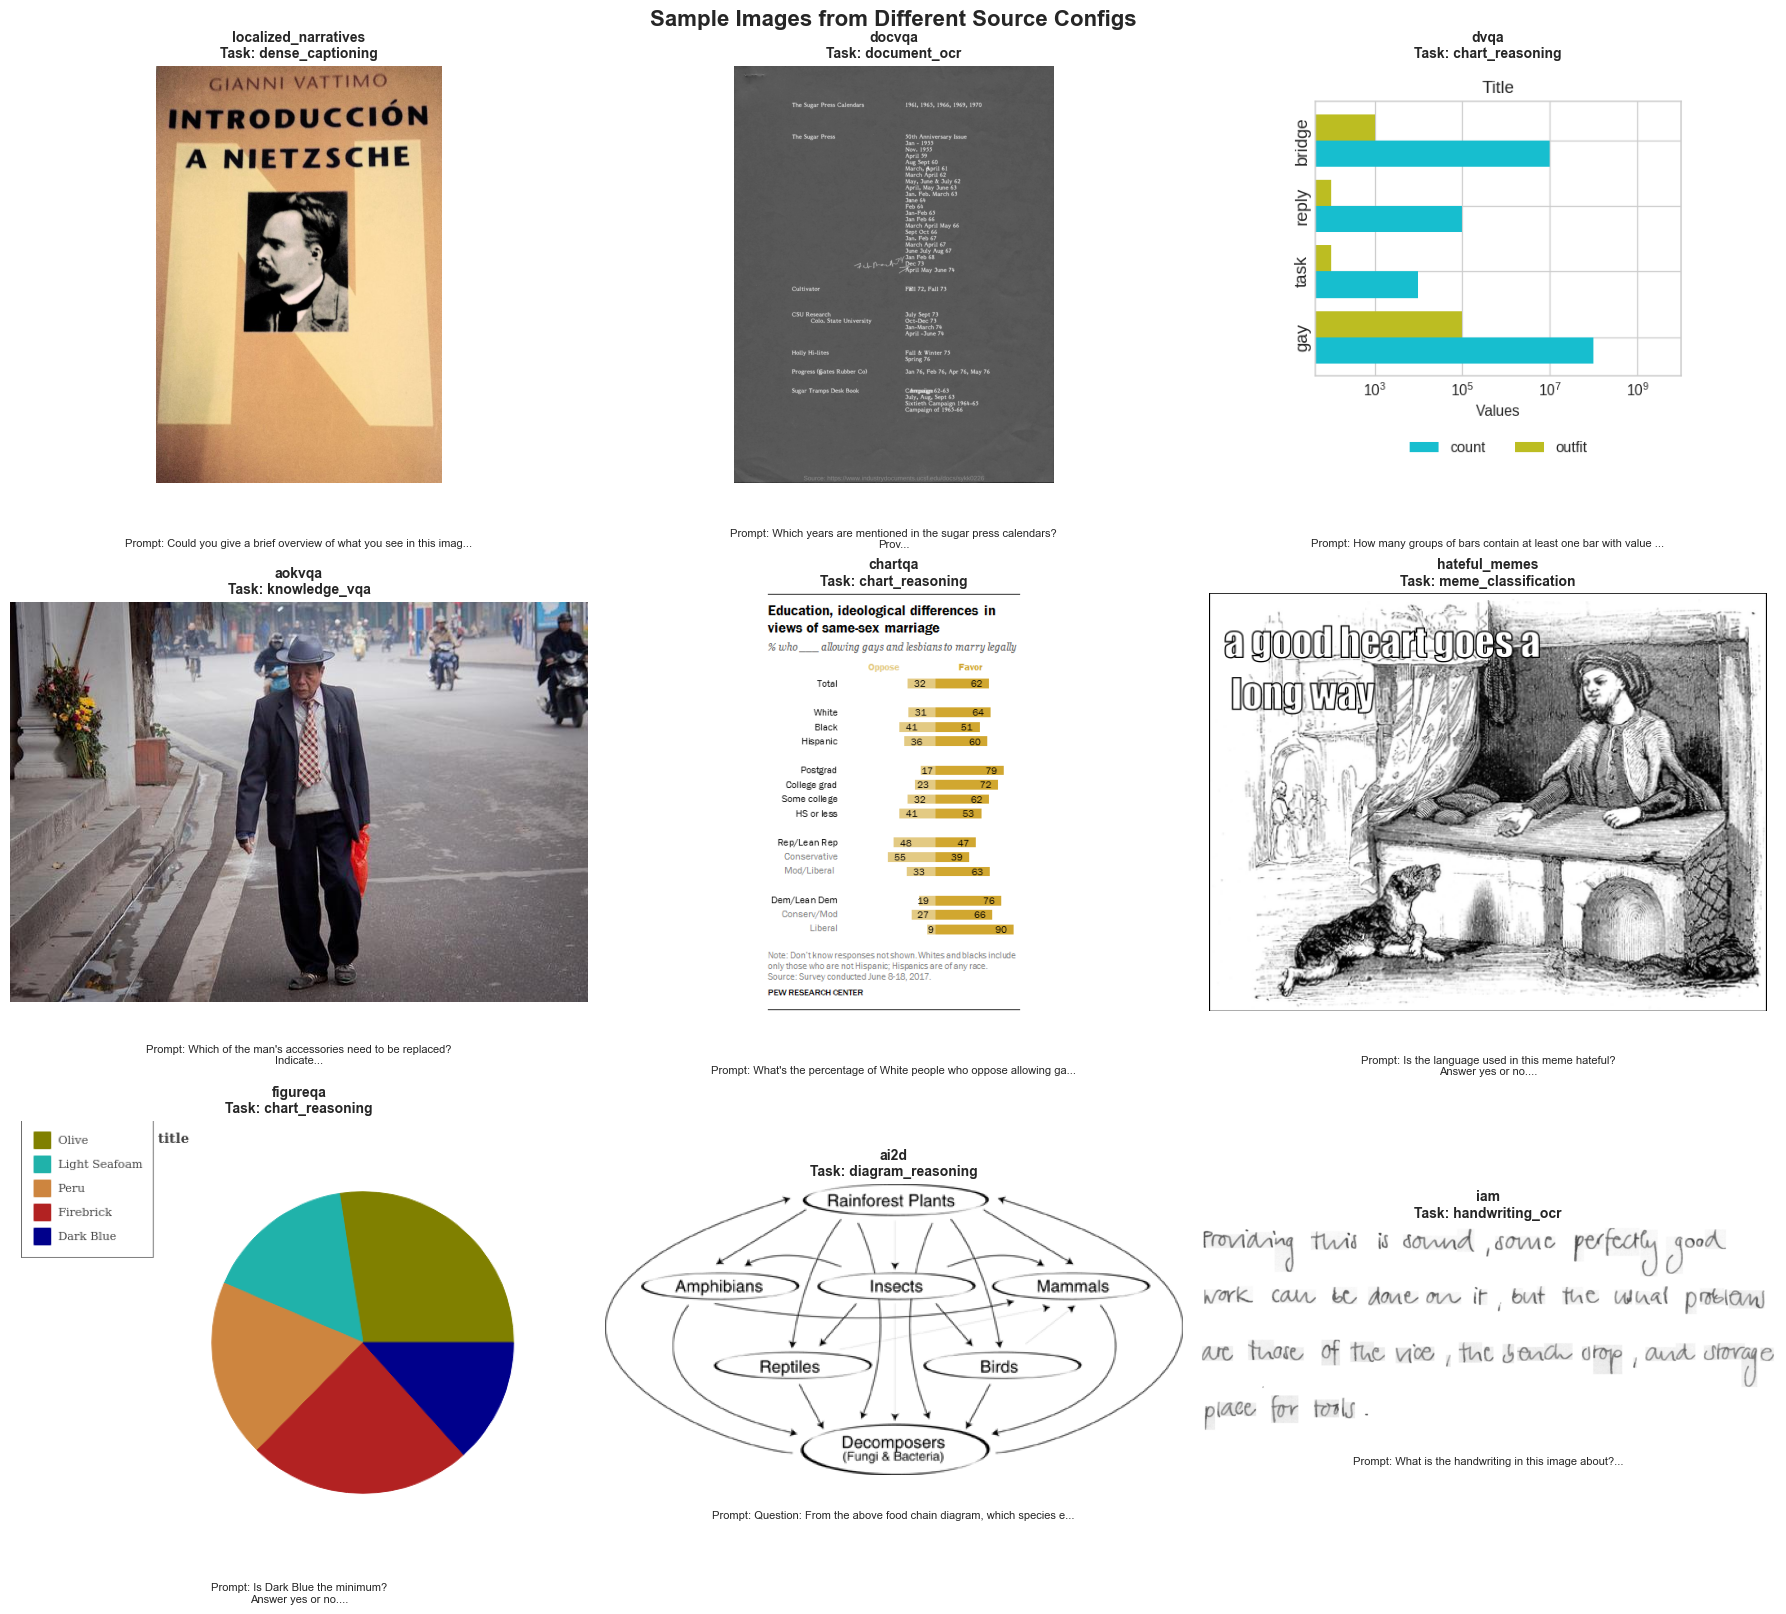

In [15]:
def load_image_from_db(image_id):
    """Load image from database by ID."""
    query = text('SELECT image_bytes FROM vlm_images WHERE image_id = :id')
    with engine.connect() as conn:
        result = conn.execute(query, {'id': image_id})
        row = result.fetchone()
        if row and row[0]:
            return Image.open(io.BytesIO(row[0]))
    return None

# Select diverse samples
configs_to_show = df_samples['source_config'].value_counts().head(9).index.tolist()
sample_images = []

for cfg in configs_to_show:
    sample = df_samples[df_samples['source_config'] == cfg].iloc[0]
    sample_images.append({
        'config': cfg,
        'task': sample['router_task'],
        'image_id': sample['image_id'],
        'prompt': sample['prompt_text'][:100] + '...' if len(sample['prompt_text']) > 100 else sample['prompt_text'],
        'gt': sample['ground_truth'][:80] + '...' if len(sample['ground_truth']) > 80 else sample['ground_truth']
    })

# Display images
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, sample_info in enumerate(sample_images):
    if idx >= 9:
        break
    
    img = load_image_from_db(sample_info['image_id'])
    if img:
        axes[idx].imshow(img)
        title = f"{sample_info['config']}\nTask: {sample_info['task']}"
        axes[idx].set_title(title, fontsize=10, fontweight='bold')
        axes[idx].axis('off')
        
        # Add text below image
        axes[idx].text(0.5, -0.15, f"Prompt: {sample_info['prompt'][:60]}...",
                      transform=axes[idx].transAxes, ha='center', fontsize=8,
                      wrap=True)

plt.suptitle('Sample Images from Different Source Configs', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

---
## 7. Dataset Completeness & Quality

Check for missing data and quality issues.

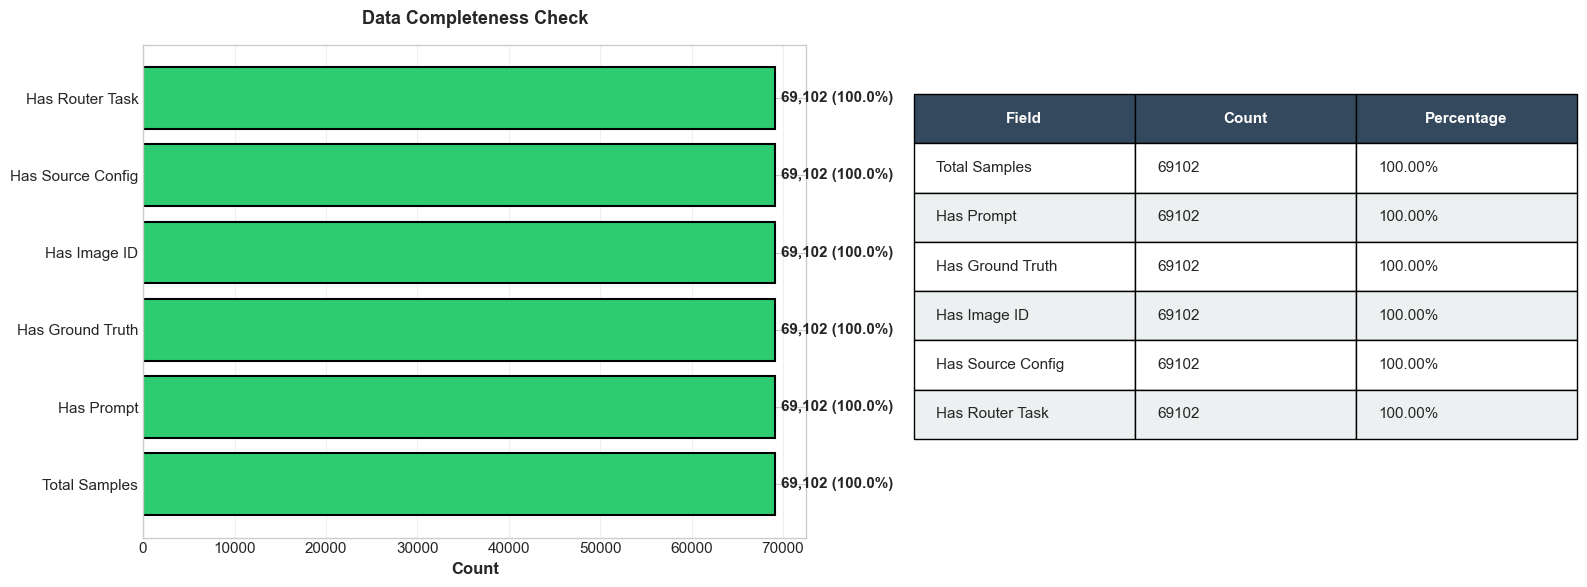


DATA COMPLETENESS SUMMARY
✓ Total Samples                 69,102 / 69,102 (100.00%)
✓ Has Prompt                    69,102 / 69,102 (100.00%)
✓ Has Ground Truth              69,102 / 69,102 (100.00%)
✓ Has Image ID                  69,102 / 69,102 (100.00%)
✓ Has Source Config             69,102 / 69,102 (100.00%)
✓ Has Router Task               69,102 / 69,102 (100.00%)


In [16]:
# === 7.1: Completeness Check ===
completeness = {
    'Total Samples': len(df_samples),
    'Has Prompt': df_samples['prompt_text'].notna().sum(),
    'Has Ground Truth': df_samples['ground_truth'].notna().sum(),
    'Has Image ID': df_samples['image_id'].notna().sum(),
    'Has Source Config': df_samples['source_config'].notna().sum(),
    'Has Router Task': df_samples['router_task'].notna().sum(),
}

df_completeness = pd.DataFrame([
    {'Field': k, 'Count': v, 'Percentage': f"{v/len(df_samples)*100:.2f}%"}
    for k, v in completeness.items()
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
colors = ['#2ecc71' if v == len(df_samples) else '#e74c3c' for v in completeness.values()]
bars = ax1.barh(list(completeness.keys()), list(completeness.values()),
                color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Data Completeness Check', pad=15)
ax1.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, completeness.values()):
    pct = val / len(df_samples) * 100
    ax1.text(val + len(df_samples)*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)', va='center', fontweight='bold')

# Table
ax2.axis('off')
table = ax2.table(cellText=df_completeness.values, colLabels=df_completeness.columns,
                  cellLoc='left', loc='center', bbox=[0, 0.2, 1, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(3):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(df_completeness)+1):
    for j in range(3):
        table[(i, j)].set_edgecolor('black')
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DATA COMPLETENESS SUMMARY")
print("="*70)
for k, v in completeness.items():
    status = "" if v == len(df_samples) else ""
    print(f"{status} {k:25} {v:>10,} / {len(df_samples):,} ({v/len(df_samples)*100:.2f}%)")
print("="*70)

---
## 8. Final Summary Statistics

In [17]:
print("\n" + "="*80)
print(" " * 20 + "VLM ROUTER BENCHMARK DATASET SUMMARY")
print("="*80)
print()
print(" DATASET SIZE:")
print(f"   Total Samples:              {len(df_samples):>12,}")
print(f"   Total Images:               {df_samples['image_id'].nunique():>12,}")
print(f"   Total Responses (5 models): {len(df_samples) * 5:>12,}")
print()
print(" COMPOSITION:")
print(f"   Source Configs:             {df_samples['source_config'].nunique():>12}")
print(f"   Router Tasks:               {df_samples['router_task'].nunique():>12}")
print(f"   Ground Truth Types:         {df_samples['ground_truth_type'].nunique():>12}")
print()
print(" TEXT STATISTICS:")
print(f"   Avg Prompt Length:          {df_samples['txt_prompt_length_chars'].mean():>12.1f} chars")
print(f"   Avg GT Length:              {df_samples['gt_length_chars'].mean():>12.1f} chars")
print()
print("️  IMAGE STATISTICS:")
print(f"   Avg Width:                  {df_images['img_width'].mean():>12.0f} px")
print(f"   Avg Height:                 {df_images['img_height'].mean():>12.0f} px")
print(f"   Avg Aspect Ratio:           {df_images['img_aspect_ratio'].mean():>12.2f}")
print(f"   Avg File Size:              {df_images['img_size_kb'].mean():>12.0f} KB")
print()
print(" DATA SPLITS:")
for split in ['train', 'val', 'test']:
    count = (df_samples['data_split'] == split).sum()
    pct = count / len(df_samples) * 100
    print(f"   {split.upper():5}                       {count:>12,} ({pct:>5.1f}%)")
print()
print(" MODELS EVALUATED:")
for model in MODEL_NAMES:
    print(f"   - {model}")
print()
print("="*80)
print(f"{'Dataset ready for VLM routing research!':^80}")
print("="*80)


                    VLM ROUTER BENCHMARK DATASET SUMMARY

📊 DATASET SIZE:
   Total Samples:                    69,102
   Total Images:                     60,452
   Total Responses (5 models):      345,510

📁 COMPOSITION:
   Source Configs:                       48
   Router Tasks:                         30
   Ground Truth Types:                    4

📏 TEXT STATISTICS:
   Avg Prompt Length:                 219.9 chars
   Avg GT Length:                     188.2 chars

🖼️  IMAGE STATISTICS:
   Avg Width:                           740 px
   Avg Height:                          617 px
   Avg Aspect Ratio:                   1.62
   Avg File Size:                       247 KB

📦 DATA SPLITS:
   TRAIN                             48,506 ( 70.2%)
   VAL                               10,418 ( 15.1%)
   TEST                              10,178 ( 14.7%)

🤖 MODELS EVALUATED:
   - deepseek_ocr
   - qwen2_5_vl_3b
   - qwen2_5_vl_7b
   - qwen3_vl_8b_thinking
   - gemma_3_27b

                    D